In [71]:
import os
from glob import glob
import pandas as pd
import geopandas as gpd
import numpy as np
from spectral.io import envi
import matplotlib.pyplot as plt

%matplotlib widget

os.chdir('/store/carroll/col/data/2025/')

In [2]:
insitu = pd.read_csv('insitu/insitu_validation_target_mean.csv')

def closest_wl(wl, mv):
    return np.nanargmin(np.abs(wl-mv))
    
wl_neon = np.loadtxt('/store/carroll/col/data/wavelengths_neon.txt')[:,1]*1000 # nm
wvl_col_neon = [f'w{x}' for x in wl_neon]
wl_asd = np.loadtxt('/store/carroll/col/data/wavelengths_asd.txt')[:,0]
wvl_col_asd = [str(round(x)) for x in wl_asd]
wl_neon_nan = np.loadtxt('/store/carroll/col/data/wl_nan.txt')
wl_neon_nan[0:4] = np.nan
wl_neon_nan[-13:] = np.nan
wl_neon_nan[closest_wl(wl_neon_nan, 1355.388672)] = np.nan
wl_neon_nan[closest_wl(wl_neon_nan, 1350)] = np.nan
wl_neon_nan[closest_wl(wl_neon_nan, 1345)] = np.nan

wl_asd[closest_wl(wl_asd, 1360):closest_wl(wl_asd, 1410)] = np.nan
wl_asd[closest_wl(wl_asd, 1800):closest_wl(wl_asd, 1970)] = np.nan

In [36]:
fp = 'validation/rfl_insitu_neon_hrdf.csv'
df_neon = pd.read_csv(fp)

fp = 'validation/rfl_insitu_deploy6c20260214.csv'
df_6c = pd.read_csv(fp)
columns = [x.replace('rfl_','') for x in df_6c.columns]
df_6c.columns = columns

df_neon_mean = df_neon.groupby(['target','fid'], as_index=False).mean()
df_6c_mean = df_6c.groupby(['target','fid'], as_index=False).mean()

targets = ['airpark', '317_veg_slope', 'matterhorn_lot', 'rainbow_park_grass', 'baseball_grass', 'low_talus_slope'] # either pseudo-invariant, or within a few days (6)
targets_final = ['airpark', 'rainbow_park_grass', 'low_talus_slope'] # choose one grass
targets_all = df_6c.target.unique()

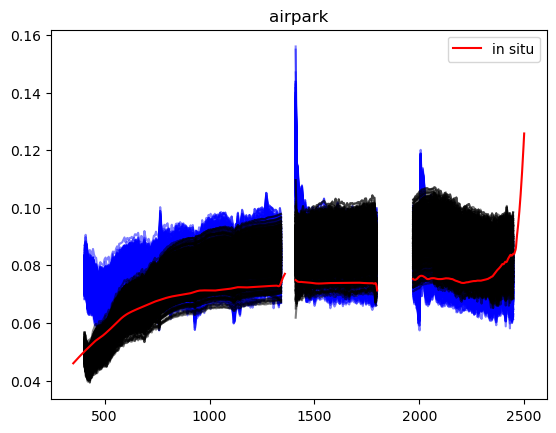

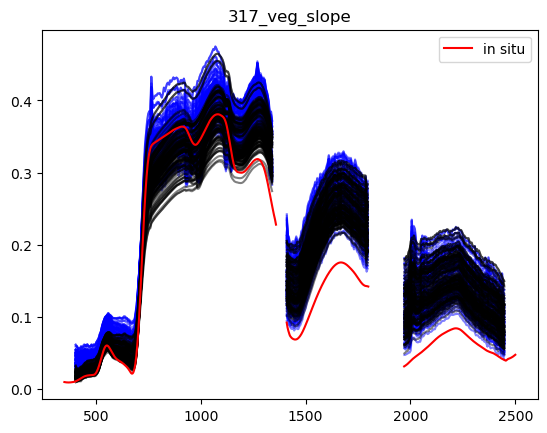

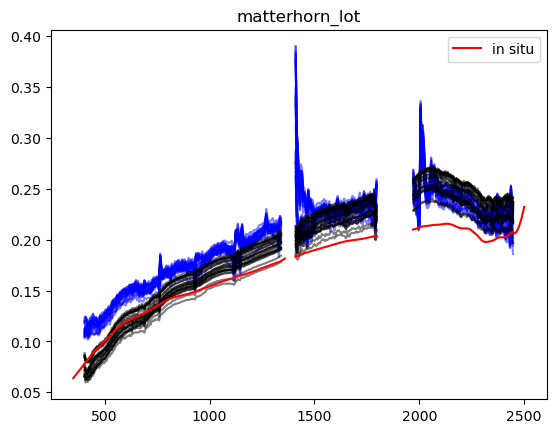

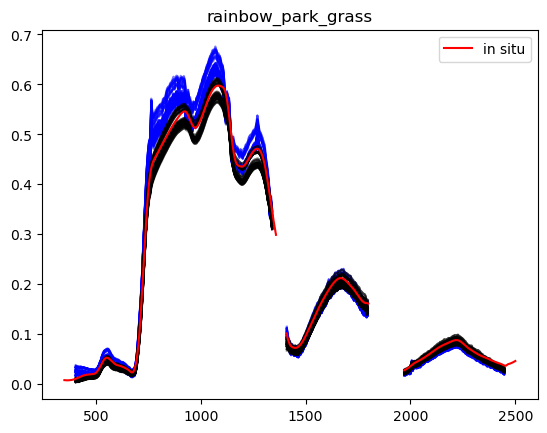

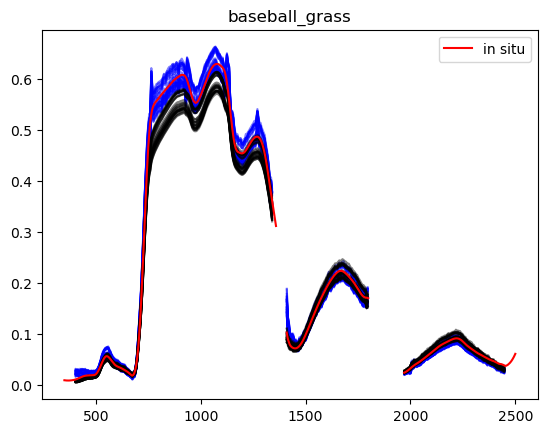

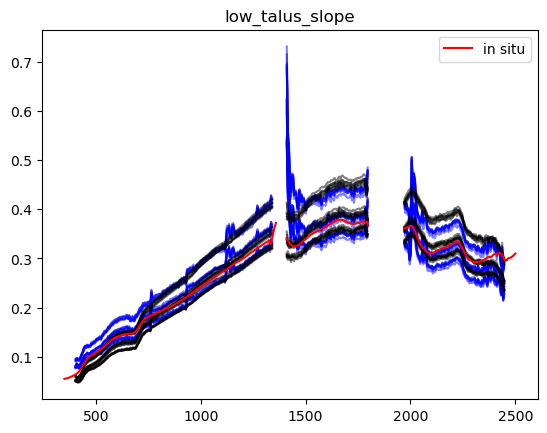

In [39]:
# neon vs isofit - all px per site
for t in targets:
    tmp = insitu[insitu['site']==t][wvl_col_asd]
    
    tmp_neon = df_neon[df_neon['target']==t]
    rfl_neon = tmp_neon[wvl_col_neon]/10000
    tmp_6c = df_6c[df_6c['target']==t]
    rfl_6c = tmp_6c[wvl_col_neon]

    fig = plt.figure()
    
    plt.plot(wl_neon_nan, rfl_neon.T, color='blue', alpha=0.5)
    plt.plot(wl_neon_nan, rfl_6c.T, color='black', alpha=0.5)

    plt.plot(wl_asd, tmp.T, label='in situ', color='red')

    plt.legend()
    plt.title(t)
    plt.show()

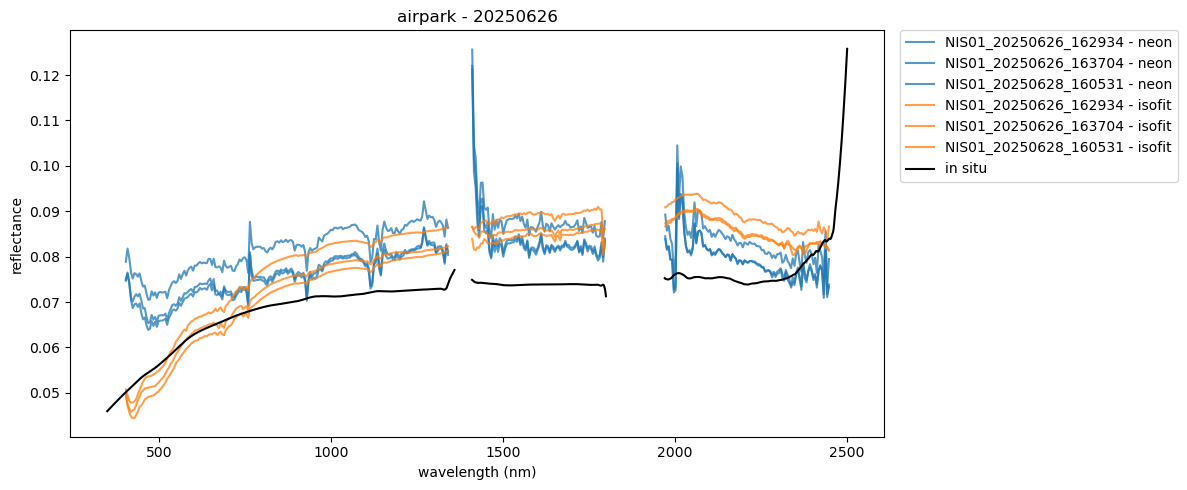

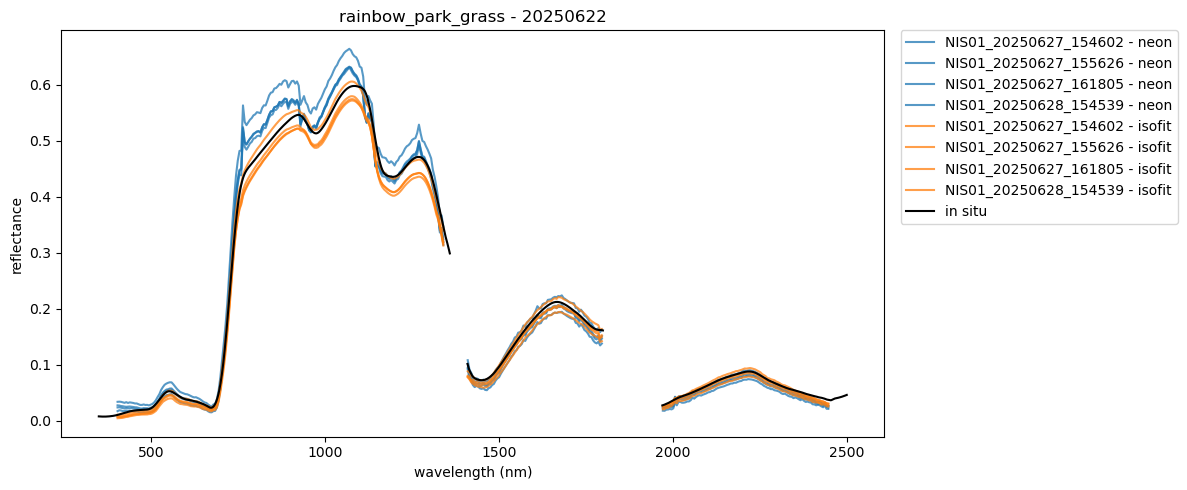

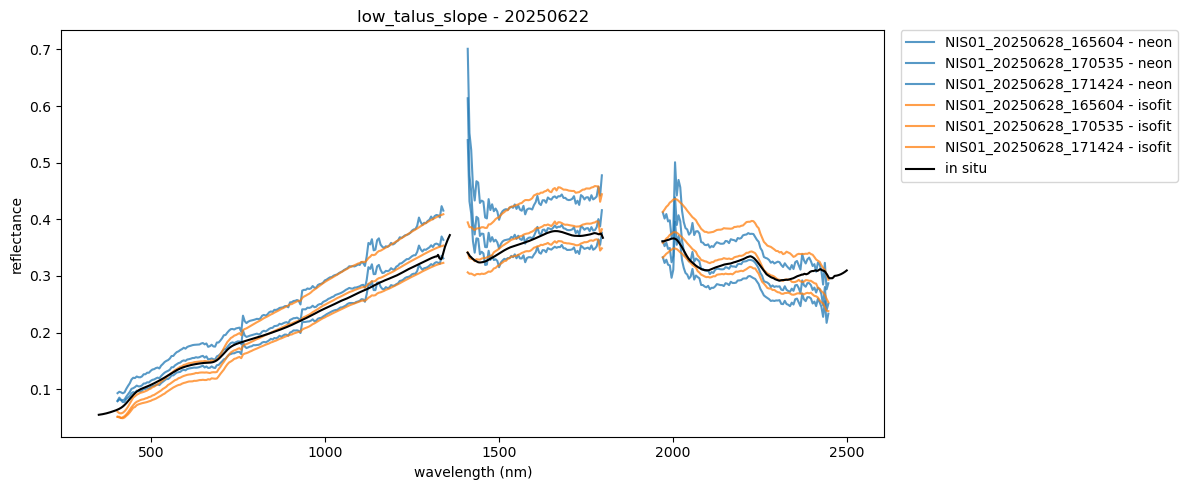

In [40]:
# neon vs isofit - mean per site
for t in targets_final:
    tmp = insitu[insitu['site']==t]
    date_insitu = tmp['date'].unique()[0]
    tmp_rfl = tmp[wvl_col_asd]
    
    tmp_neon = df_neon_mean[df_neon_mean['target']==t]
    rfl_neon = tmp_neon[wvl_col_neon]/10000
    dates_neon = [x+' - neon' for x in tmp_neon['fid']]
    
    tmp_6c = df_6c_mean[df_6c_mean['target']==t]
    rfl_6c = tmp_6c[wvl_col_neon]
    dates_6c = [x+' - isofit' for x in tmp_6c['fid']]
    
    fig, ax = plt.subplots(figsize=(12,5))

    # plt.fill_between(wl_neon_nan, lower.T, upper.T, alpha=0.3, label="± Uncertainty")
    ax.plot(wl_neon_nan, rfl_neon.T, alpha=0.75, label=dates_neon, color='#1f77b4')
    ax.plot(wl_neon_nan, rfl_6c.T, alpha=0.75, label=dates_6c, color='#ff7f0e')

    ax.plot(wl_asd, tmp_rfl.T, label='in situ', color='black')
    ax.set_title(f'{t} - {date_insitu}')
    ax.set_xlabel('wavelength (nm)')
    ax.set_ylabel('reflectance')
    
    ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
    )
    fig.tight_layout()
    
    plt.show()

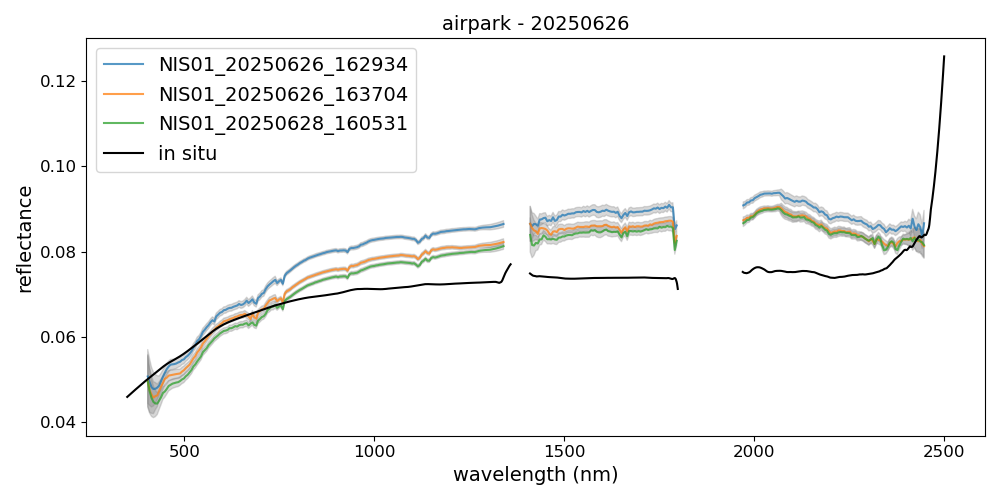

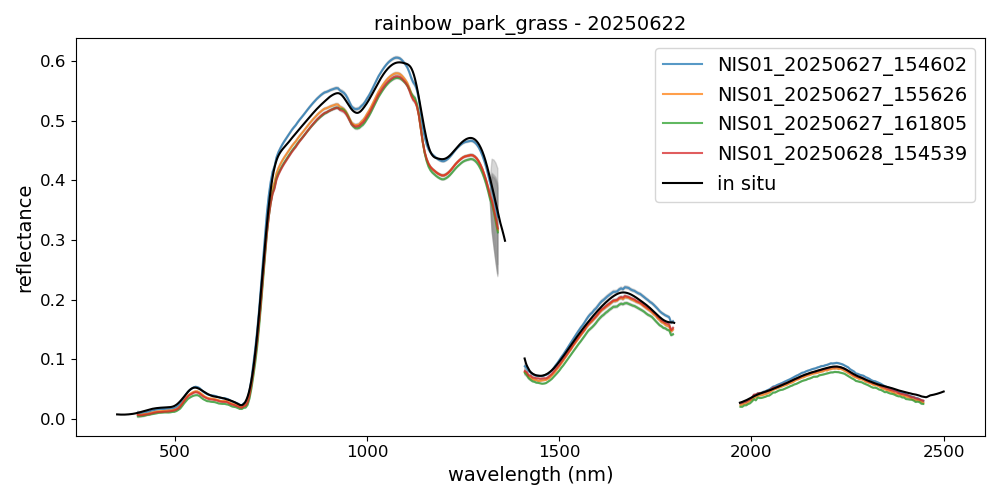

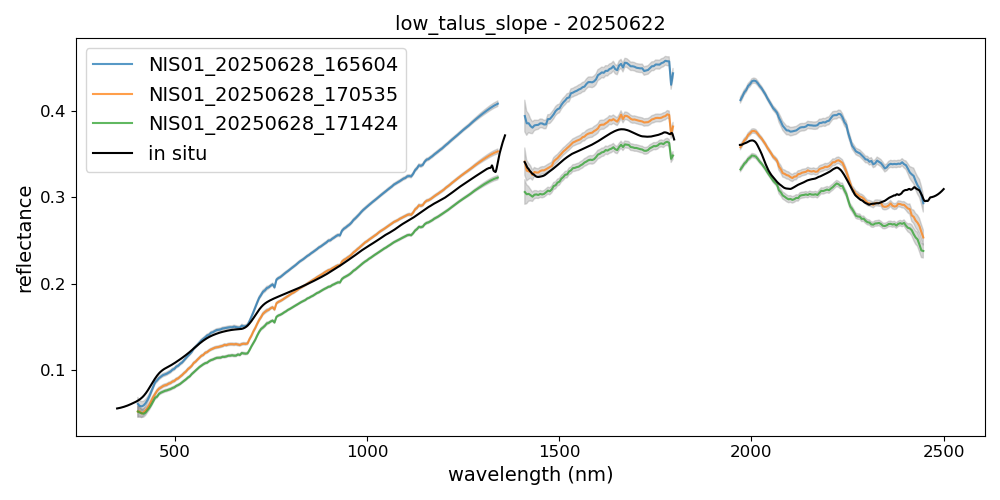

In [90]:
# mean isofit w uncertainty

fontsize = 14

for t in targets_final:
    tmp = insitu[insitu['site']==t]
    date_insitu = tmp['date'].unique()[0]
    tmp_rfl = tmp[wvl_col_asd]
    
    tmp_6c = df_6c_mean[df_6c_mean['target']==t]
    rfl_6c = np.asarray(tmp_6c[wvl_col_neon])
    unc = np.asarray(tmp_6c[['unc_'+x for x in wvl_col_neon]])
    dates_6c = [x for x in tmp_6c['fid']]
    lower = rfl_6c - unc
    upper = rfl_6c + unc

    fig, ax = plt.subplots(figsize=(10,5))

    for i in range(rfl_6c.shape[0]):
        plt.fill_between(wl_neon_nan, lower[i,:], upper[i,:], alpha=0.3, color='gray') #, label="± Uncertainty"
        ax.plot(wl_neon_nan, rfl_6c[i,:], alpha=0.75, label=dates_6c[i]) # color='#1f77b4'

    ax.plot(wl_asd, tmp_rfl.T, label='in situ', color='black')
    ax.set_title(f'{t} - {date_insitu}', fontsize=fontsize)
    ax.set_xlabel('wavelength (nm)', fontsize=fontsize)
    ax.set_ylabel('reflectance', fontsize=fontsize)
    ax.tick_params(axis='both', labelsize=fontsize-2)

    ax.legend(fontsize=fontsize)
    
    plt.tight_layout()
    plt.show()

(6, 852) (6, 852)


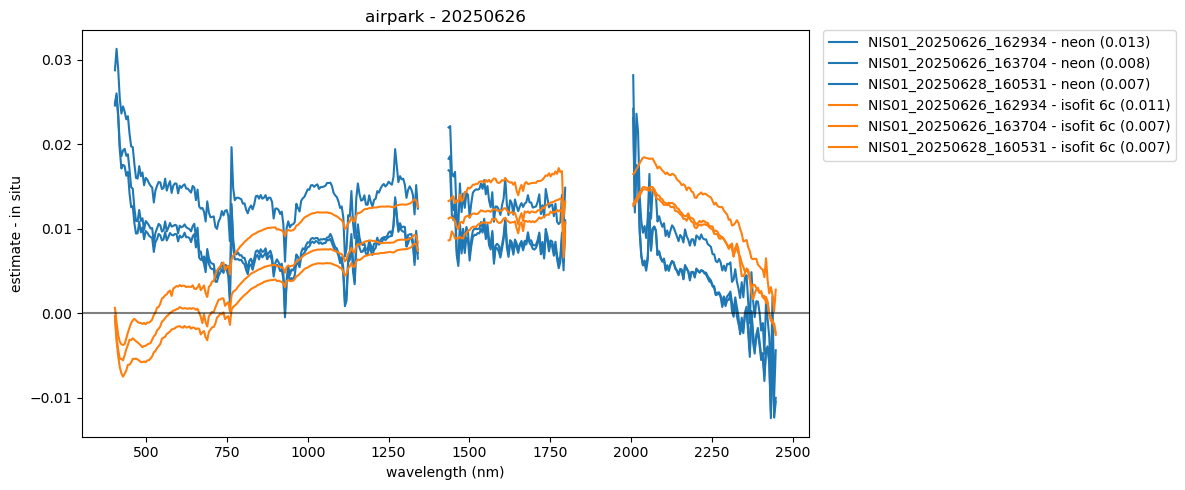

(7, 852) (7, 852)


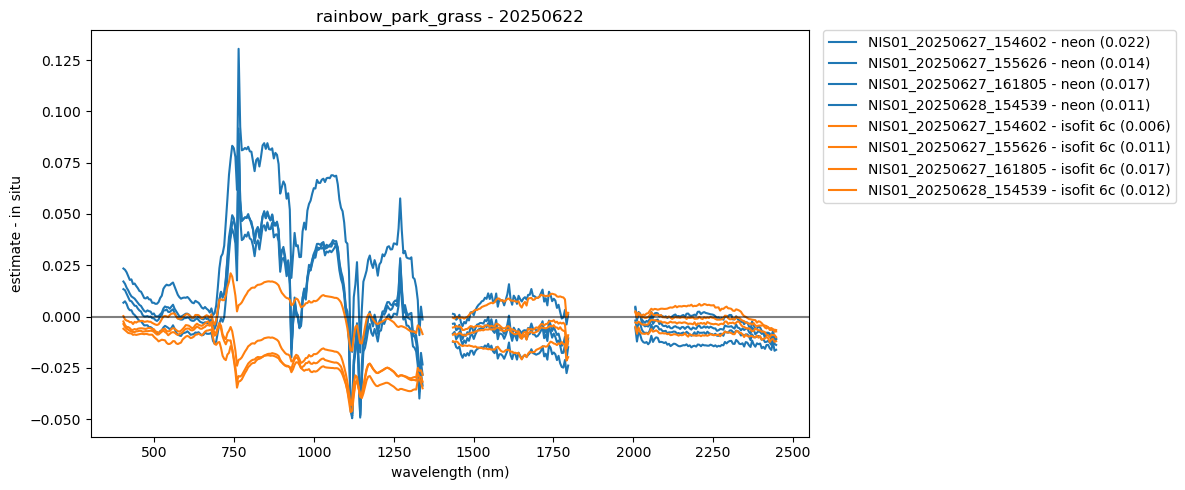

(3, 852) (3, 852)


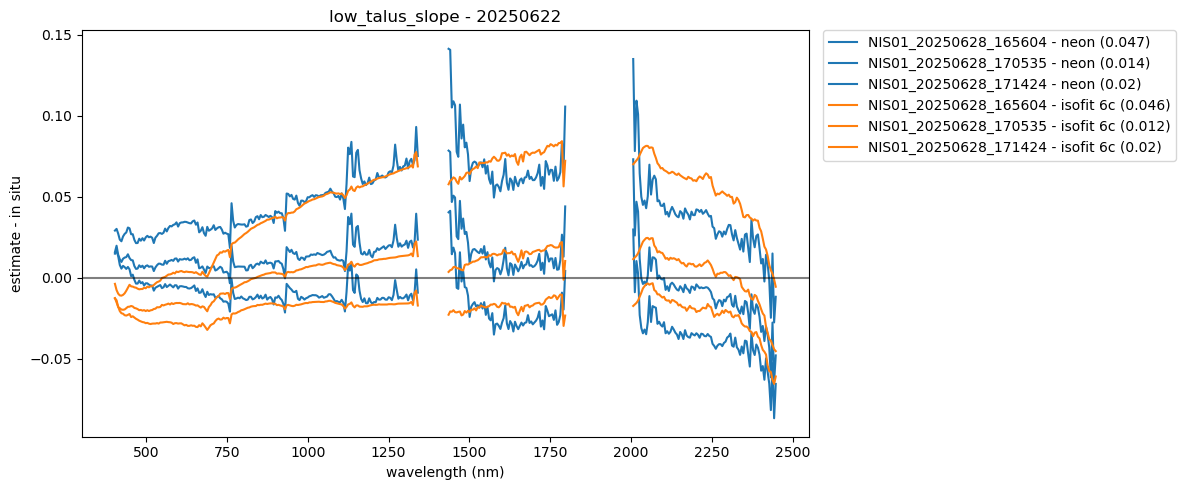

In [42]:
# neon vs isofit - mean absolute error per flightline
keep_wl = np.asarray(wvl_col_neon)[~np.isnan(wl_neon_nan)]

for t in targets_final:
    tmp = insitu[insitu['site']==t]
    date_insitu = tmp['date'].unique()[0]
    tmp_rfl = tmp[wvl_col_asd]
    tmp_rfl = np.interp(wl_neon, wl_asd, tmp_rfl.squeeze())
    
    tmp_neon = df_neon_mean[df_neon_mean['target']==t]
    rfl_neon = tmp_neon[wvl_col_neon]/10000
    error_neon = rfl_neon - tmp_rfl
    mean_error_neon = np.nanmean(abs(np.asarray(error_neon[keep_wl])), axis=1)
    dates_neon = [x+' - neon'+f' ({round(y, 3)})' for x, y in zip(tmp_neon['fid'], mean_error_neon)]

    tmp_6c = df_6c_mean[df_6c_mean['target']==t]
    rfl_6c = tmp_6c[wvl_col_neon]
    error_6c = rfl_6c - tmp_rfl
    mean_error_6c = np.nanmean(abs(np.asarray(error_6c[keep_wl])), axis=1)
    dates_6c = [x+' - isofit 6c'+f' ({round(y, 3)})' for x, y in zip(tmp_6c['fid'], mean_error_6c)]
    upper = rfl_6c + unc_6c
    lower = rfl_6c - unc_6c
    print(lower.shape, upper.shape)
    
    fig, ax = plt.subplots(figsize=(12,5))
    
    ax.plot(wl_neon_nan, error_neon.T, label=dates_neon, color='#1f77b4')
    ax.plot(wl_neon_nan, error_6c.T, label=dates_6c, color='#ff7f0e')

    plt.axhline(y=0, color='black', alpha=0.5)
    ax.set_title(f'{t} - {date_insitu}')
    ax.set_ylabel('estimate - in situ')
    ax.set_xlabel('wavelength (nm)')
    
    ax.legend(
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
    )
    fig.tight_layout()
    
    plt.show()

In [91]:
# table - mae per flightline
keep_wl = np.asarray(wvl_col_neon)[~np.isnan(wl_neon_nan)]

df = []
for t in targets_final:
    tmp = insitu[insitu['site']==t]
    date_insitu = tmp['date'].unique()[0]
    tmp_rfl = tmp[wvl_col_asd]
    tmp_rfl = np.interp(wl_neon, wl_asd, tmp_rfl.squeeze())
    
    tmp_neon = df_neon_mean[df_neon_mean['target']==t]
    rfl_neon = tmp_neon[wvl_col_neon]/10000
    error_neon = rfl_neon - tmp_rfl
    mean_error_neon = np.nanmean(abs(np.asarray(error_neon[keep_wl])), axis=1)

    tmp_6c = df_6c_mean[df_6c_mean['target']==t]
    rfl_6c = tmp_6c[wvl_col_neon]
    error_6c = rfl_6c - tmp_rfl
    mean_error_6c = np.nanmean(abs(np.asarray(error_6c[keep_wl])), axis=1)

    df_ = pd.DataFrame({'target': t,
                        'date_insitu_measurement': date_insitu,
                        'fid': tmp_neon['fid'],
                        'mae_isofit': mean_error_6c,
                        'mae_neon': mean_error_neon
                       })
    df.append(df_)

df = pd.concat(df, ignore_index=True)
df

,target,date_insitu_measurement,fid,mae_isofit,mae_neon
0,airpark,20250626,NIS01_20250626_162934,0.010574,0.012507
1,airpark,20250626,NIS01_20250626_163704,0.007490,0.007891
2,airpark,20250626,NIS01_20250628_160531,0.006889,0.007394
3,rainbow_park_grass,20250622,NIS01_20250627_154602,0.005698,0.021766
4,rainbow_park_grass,20250622,NIS01_20250627_155626,0.011165,0.013624
5,rainbow_park_grass,20250622,NIS01_20250627_161805,0.017138,0.017035
6,rainbow_park_grass,20250622,NIS01_20250628_154539,0.011701,0.011219
7,low_talus_slope,20250622,NIS01_20250628_165604,0.046119,0.047458
8,low_talus_slope,20250622,NIS01_20250628_170535,0.011909,0.014059
9,low_talus_slope,20250622,NIS01_20250628_171424,0.020466,0.019676


In [45]:
# table - mae per site
df_mean = df.drop(columns=['fid']).groupby(['target', 'date_insitu_measurement'], as_index=False).mean()
df_mean

,target,date_insitu_measurement,mae_isofit,mae_neon
0,airpark,20250626,0.008318,0.009264
1,low_talus_slope,20250622,0.026165,0.027064
2,rainbow_park_grass,20250622,0.011425,0.015911


In [80]:
# mae across sites
df_mean.mae_isofit.mean()

0.0153026622849347